# 01: SMILES Strings - Writing Molecules as Text

## What is this notebook about?

Before a computer can "understand" a molecule, we need a way to write the molecule down as text. Think of it like sheet music: a real symphony is sound, but we can encode it as symbols on a page so it can be stored, shared, and processed.

**SMILES** (Simplified Molecular Input Line Entry System) is the most widely used system for writing molecules as text strings. This notebook explains:
- What SMILES strings are and how to read them
- How to turn SMILES into machine-readable tokens (like words in a sentence)
- Why this matters for machine learning on molecules

---

## The core idea: molecules as sentences

In natural language processing (NLP), a sentence like `"the cat sat"` gets broken into words (tokens): `["the", "cat", "sat"]`. Each word maps to a number. A model processes those numbers.

We do the same with molecules:
- The **molecule** is like a sentence
- The **SMILES string** is how we write that sentence
- **Tokenization** breaks it into atoms and bonds (the "words")
- **Encoding** converts those tokens into numbers a model can process

---

## Part 1: Reading SMILES - the basics

### Atoms
Most atoms are written as their chemical symbol:
- `C` = carbon
- `N` = nitrogen  
- `O` = oxygen
- `F`, `Cl`, `Br`, `I` = halogens (note: `Cl` and `Br` are two-letter tokens!)
- Lowercase letters (`c`, `n`, `o`) = **aromatic** atoms (part of a ring like benzene)

### Bonds
- Single bond: implied (no symbol needed between adjacent atoms)
- Double bond: `=`
- Triple bond: `#`
- Aromatic bond: `:` (or implied between lowercase atoms)

### Branches
- Parentheses `(...)` indicate a branch off the main chain, just like a side chain on an amino acid

### Rings
- Numbers indicate where a ring opens and closes: `C1CCCCC1` = cyclohexane (ring opens at first `1`, closes at second `1`)

### Examples to build intuition

| Molecule | SMILES | What to notice |
|---|---|---|
| Methane | `C` | Just one carbon |
| Ethanol | `CCO` | Two carbons, one oxygen |
| Acetic acid | `CC(=O)O` | Branch: `=O` (double bond oxygen) off the chain |
| Benzene | `c1ccccc1` | Aromatic ring: lowercase + ring closure |
| Aspirin | `CC(=O)Oc1ccccc1C(=O)O` | Ester linkage to an aromatic ring with a carboxylic acid |
| Caffeine | `CN1C=NC2=C1C(=O)N(C(=O)N2C)C` | Two fused rings, multiple nitrogens |

In [1]:
# Let's start by just working with SMILES as plain Python strings.
# No special libraries needed yet!

# A small collection of biologically relevant molecules
molecules = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Caffeine":     "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Paracetamol":  "CC(=O)Nc1ccc(O)cc1",
    "Penicillin G": "CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)Cc3ccccc3)C(=O)O)C",
    "Glucose":      "OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",
    "Dopamine":     "NCCc1ccc(O)c(O)c1",
    "Serotonin":    "NCCc1c[nH]c2ccc(O)cc12",
}

for name, smiles in molecules.items():
    print(f"{name:15s} | length: {len(smiles):3d} chars | {smiles}")

Aspirin         | length:  21 chars | CC(=O)Oc1ccccc1C(=O)O
Ibuprofen       | length:  26 chars | CC(C)Cc1ccc(cc1)C(C)C(=O)O
Caffeine        | length:  28 chars | CN1C=NC2=C1C(=O)N(C(=O)N2C)C
Paracetamol     | length:  18 chars | CC(=O)Nc1ccc(O)cc1
Penicillin G    | length:  58 chars | CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)Cc3ccccc3)C(=O)O)C
Glucose         | length:  38 chars | OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O
Dopamine        | length:  17 chars | NCCc1ccc(O)c(O)c1
Serotonin       | length:  22 chars | NCCc1c[nH]c2ccc(O)cc12


## Part 2: Tokenization - breaking SMILES into "words"

The first challege is SMILES uses multi-character tokens. `Cl` is one atom (chlorine), not carbon + lowercase-L. Our tokenizer must handle this. 

This is analogous to how in English, `"th"` in "the" is not `t`+`h` separately - some combinations have their own meaning. 

In [2]:
# First, import regex
import re 

# Multi-character tokens must not be split:
# Cl, Br -- two-letter aroms
# @@ -- stereochemistry 
# %nn -- ring closures above ring #9 (e.g., %10, %23)

MULTI_CHAR = re.compile(r'Cl|Br|@@|%\d{2}')

def tokenize(smiles: str) -> list:
    """
    Split a SMILES string into a list of tokens.
    Handles two-character atoms (Cl, Br) and stereochemistry markers.
    """
    tokens = []
    i = 0
    while i < len(smiles):
        match = MULTI_CHAR.match(smiles, i)  # try to match a multi-char token first
        if match:
            tokens.append(match.group())
            i = match.end()
        else:
            tokens.append(smiles[i])         # otherwise, take one character
            i += 1
    return tokens


# Test on a few molecules
test_cases = [
    ("Ethanol",    "CCO"),
    ("Benzene",    "c1ccccc1"),
    ("Aspirin",    "CC(=O)Oc1ccccc1C(=O)O"),
    ("Penicillin", "CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)Cc3ccccc3)C(=O)O)C"),
]

for name, smi in test_cases:
    toks = tokenize(smi)
    print(f"\n{name}")
    print(f"  SMILES: {smi}")
    print(f"  Tokens: {toks}")
    print(f"  Count:  {len(toks)} tokens")


Ethanol
  SMILES: CCO
  Tokens: ['C', 'C', 'O']
  Count:  3 tokens

Benzene
  SMILES: c1ccccc1
  Tokens: ['c', '1', 'c', 'c', 'c', 'c', 'c', '1']
  Count:  8 tokens

Aspirin
  SMILES: CC(=O)Oc1ccccc1C(=O)O
  Tokens: ['C', 'C', '(', '=', 'O', ')', 'O', 'c', '1', 'c', 'c', 'c', 'c', 'c', '1', 'C', '(', '=', 'O', ')', 'O']
  Count:  21 tokens

Penicillin
  SMILES: CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)Cc3ccccc3)C(=O)O)C
  Tokens: ['C', 'C', '1', '(', '[', 'C', '@@', 'H', ']', '(', 'N', '2', '[', 'C', '@', 'H', ']', '(', 'S', '1', ')', '[', 'C', '@@', 'H', ']', '(', 'C', '2', '=', 'O', ')', 'N', 'C', '(', '=', 'O', ')', 'C', 'c', '3', 'c', 'c', 'c', 'c', 'c', '3', ')', 'C', '(', '=', 'O', ')', 'O', ')', 'C']
  Count:  56 tokens


## Part 3: Building a Vocabulary

In NLP, a **vocabulary** is the set of all unique words a model knows. We build the same thing for SMILES tokens.

Special tokens we always include:
- `<pad>` - padding, used to make all sequences the same length in a batch
- `<sos>` - "start of sequence", tells the decoder to begin
- `<eos>` - "end of sequence", tells the model the molecule is complete
- `<unk>` - "unknown", for tokens the model has never seen

In [3]:
from collections import Counter

# Build vocabulary from our molecule collection
all_tokens = []
for smi in molecules.values():
    all_tokens.extend(tokenize(smi))

token_counts = Counter(all_tokens)
print("Token frequencies across all molecules:")
for tok, count in token_counts.most_common():
    print(f"  {tok!r:8s}  -->  {count} occurrences")

Token frequencies across all molecules:
  'C'       -->  40 occurrences
  'c'       -->  38 occurrences
  '('       -->  23 occurrences
  'O'       -->  23 occurrences
  ')'       -->  23 occurrences
  '1'       -->  16 occurrences
  '='       -->  11 occurrences
  'N'       -->  9 occurrences
  '['       -->  8 occurrences
  'H'       -->  8 occurrences
  ']'       -->  8 occurrences
  '2'       -->  6 occurrences
  '@@'      -->  4 occurrences
  '@'       -->  3 occurrences
  '3'       -->  2 occurrences
  'S'       -->  1 occurrences
  'n'       -->  1 occurrences


In [4]:
# Now build the full vocabulary with special tokens at the front

SPECIAL_TOKENS = ["<pad>", "<sos>", "<eos>", "<unk>"]

# A standard SMILES vocabulary covering most drug-like molecules
SMILES_CHARS = [
    "C", "c", "N", "n", "O", "o", "S", "s", "F", "Cl", "Br", "I",
    "P", "p", "B", "b",
    "1", "2", "3", "4", "5", "6", "7", "8", "9", "0",
    "(", ")", "[", "]", "=", "#", "-", "+", "/", "\\", "@", "%", ".",
]

VOCAB = SPECIAL_TOKENS + SMILES_CHARS
CHAR2IDX = {ch: i for i, ch in enumerate(VOCAB)}
IDX2CHAR = {i: ch for ch, i in CHAR2IDX.items()}

PAD_IDX = CHAR2IDX["<pad>"]   # 0
SOS_IDX = CHAR2IDX["<sos>"]   # 1
EOS_IDX = CHAR2IDX["<eos>"]   # 2
UNK_IDX = CHAR2IDX["<unk>"]   # 3

print(f"Vocabulary size: {len(VOCAB)} tokens")
print(f"\nFirst 10 entries:")
for i, ch in list(IDX2CHAR.items())[:10]:
    print(f"  index {i:2d}  -->  {ch!r}")

Vocabulary size: 43 tokens

First 10 entries:
  index  0  -->  '<pad>'
  index  1  -->  '<sos>'
  index  2  -->  '<eos>'
  index  3  -->  '<unk>'
  index  4  -->  'C'
  index  5  -->  'c'
  index  6  -->  'N'
  index  7  -->  'n'
  index  8  -->  'O'
  index  9  -->  'o'


## Part 4: Encoding and Decoding

Now we can convert a SMILES string --> a list of integers, and back again.

This is the fundamental transformation that lets a neural network process molecules.

In [5]:
import numpy as np

def encode_smiles(smiles: str, max_len: int = 120) -> np.ndarray | None:
    """
    Convert a SMILES string to a fixed-length integer array

    Layout: [<sos>, tok1, tok2, ..., tokN, <eos>, <pad>, <pad>, ...]

    Returns None if the molecule is too long for max_len
    """
    tokens = tokenize(smiles)

    if len(tokens) + 2 > max_len:   # +2 accounts for <sos> and <eos>
        return None

    # Build index list
    ids = [SOS_IDX]                                          # start token
    ids += [CHAR2IDX.get(t, UNK_IDX) for t in tokens]       # molecule tokens
    ids += [EOS_IDX]                                         # end token
    ids += [PAD_IDX] * (max_len - len(ids))                  # padding

    return np.array(ids, dtype=np.int32)


def decode_ids(ids: np.ndarray) -> str:
    """
    Convert an integer array back to a SMILES string.
    Stops at <eos> and strips special tokens.
    """
    result = []
    for idx in ids:
        tok = IDX2CHAR.get(int(idx), "")
        if tok == "<eos>":
            break
        if tok in ("<sos>", "<pad>", "<unk>"):
            continue
        result.append(tok)
    return "".join(result)


# Demo
aspirin = "CC(=O)Oc1ccccc1C(=O)O"
encoded = encode_smiles(aspirin, max_len=30)

print("Original SMILES: ", aspirin)
print("Tokenized:       ", tokenize(aspirin))
print("Encoded (int32): ", encoded)
print("Decoded back:    ", decode_ids(encoded))
print("\nRound-trip successful:", decode_ids(encoded) == aspirin)

Original SMILES:  CC(=O)Oc1ccccc1C(=O)O
Tokenized:        ['C', 'C', '(', '=', 'O', ')', 'O', 'c', '1', 'c', 'c', 'c', 'c', 'c', '1', 'C', '(', '=', 'O', ')', 'O']
Encoded (int32):  [ 1  4  4 30 34  8 31  8  5 20  5  5  5  5  5 20  4 30 34  8 31  8  2  0
  0  0  0  0  0  0]
Decoded back:     CC(=O)Oc1ccccc1C(=O)O

Round-trip successful: True


## Part 5: One-Hot Encoding vs. Learned Embeddings

There are two main ways to give a model numerical token representations.

### One-hot encoding
Each token becomes a vector of all zeros except for a single `1` at its index position. Simple, but the model can't learn that `C` and `c` are related.

### Learned embeddings
Each token gets a dense vector of (say) 128 numbers, learned during training. Similar tokens end up with similar vectors - the model discovers that `c` (aromatic carbon) and `C` (aliphatic carbon) are chemically related.

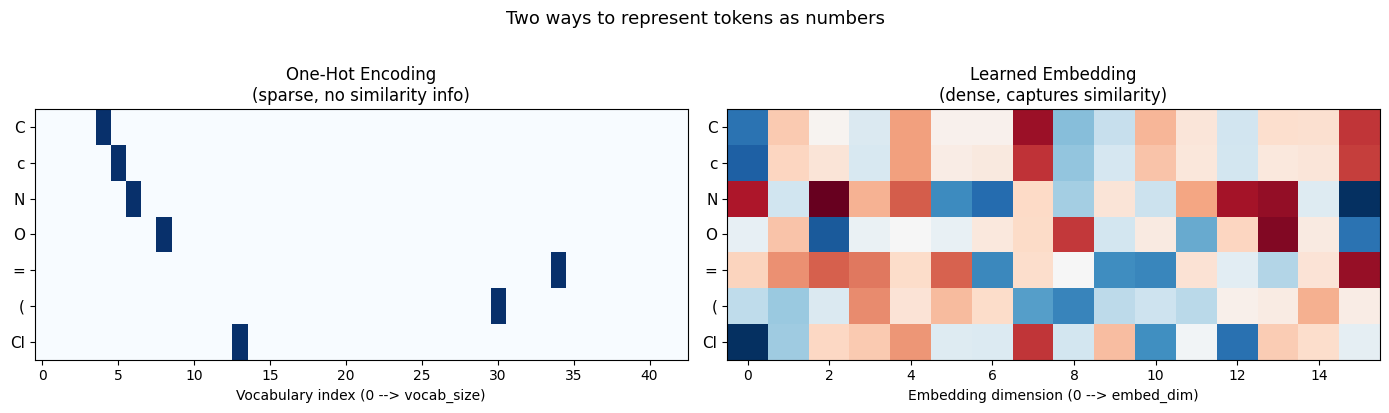

One-hot vector size: 43 (one per vocab entry)
Embedding size:      16  (learned, dense)

Note how 'C' (row 0) and 'c' (row 1) have similar embedding rows
  C  embedding: [ 0.51 -0.14  0.01  0.12 -0.24  0.   -0.   -0.53  0.31  0.18 -0.19 -0.05
  0.15 -0.08 -0.07 -0.44]
  c  embedding: [ 0.56 -0.11 -0.05  0.13 -0.24 -0.02 -0.03 -0.44  0.29  0.14 -0.16 -0.04
  0.15 -0.04 -0.05 -0.42]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# One-hot encoding
def one_hot(idx: int, vocab_size: int) -> np.ndarray:
    vec = np.zeros(vocab_size)
    vec[idx] = 1.0
    return vec

VOCAB_SIZE = len(VOCAB)

# Encode a few tokens and visualise
demo_tokens = ["C", "c", "N", "O", "=", "(", "Cl"]
oh_matrix   = np.array([one_hot(CHAR2IDX[t], VOCAB_SIZE) for t in demo_tokens])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: one-hot matrix
axes[0].imshow(oh_matrix, aspect="auto", cmap="Blues", interpolation="nearest")
axes[0].set_yticks(range(len(demo_tokens)))
axes[0].set_yticklabels(demo_tokens, fontsize=11)
axes[0].set_xlabel("Vocabulary index (0 --> vocab_size)")
axes[0].set_title("One-Hot Encoding\n(sparse, no similarity info)", fontsize=12)

# Right: mock learned embeddings (random, for illustration)
np.random.seed(7)
embed_dim  = 16
embeddings = np.random.randn(len(demo_tokens), embed_dim) * 0.3
# Make C and c slightly similar (they're both carbon)
embeddings[1] = embeddings[0] + np.random.randn(embed_dim) * 0.05

axes[1].imshow(embeddings, aspect="auto", cmap="RdBu", interpolation="nearest")
axes[1].set_yticks(range(len(demo_tokens)))
axes[1].set_yticklabels(demo_tokens, fontsize=11)
axes[1].set_xlabel("Embedding dimension (0 --> embed_dim)")
axes[1].set_title("Learned Embedding\n(dense, captures similarity)", fontsize=12)

plt.suptitle("Two ways to represent tokens as numbers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"One-hot vector size: {VOCAB_SIZE} (one per vocab entry)")
print(f"Embedding size:      {embed_dim}  (learned, dense)")
print(f"\nNote how 'C' (row 0) and 'c' (row 1) have similar embedding rows")
print(f"  C  embedding: {embeddings[0].round(2)}")
print(f"  c  embedding: {embeddings[1].round(2)}")

## Part 6: Preparing batches for a model

Neural networks process molecules in **batches** - groups of many molecules at once - for efficiency. Each molecule needs to be the same length, so we pad shorter ones with `<pad>` tokens.


Batch shape: (8, 60)  -->  (8 molecules × 60 token positions)

Visualization of encoded batch (each row = one molecule):


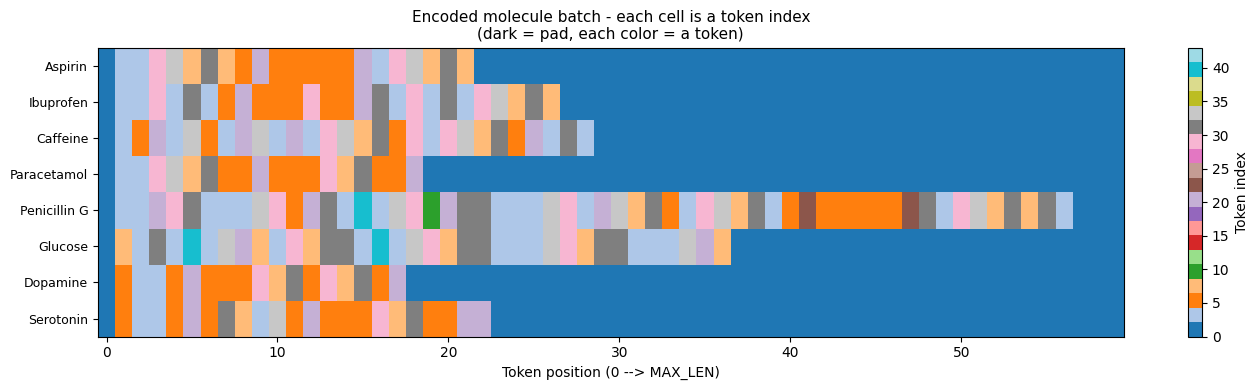

In [7]:
MAX_LEN = 60

# Encode all molecules
encoded_mols = {}
for name, smi in molecules.items():
    enc = encode_smiles(smi, max_len=MAX_LEN)
    if enc is not None:
        encoded_mols[name] = enc
    else:
        print(f"  Skipped {name} (too long for max_len={MAX_LEN})")

# Stack into a 2D array: shape (n_molecules, MAX_LEN)
names  = list(encoded_mols.keys())
batch  = np.stack(list(encoded_mols.values()))   # shape: (N, MAX_LEN)

print(f"\nBatch shape: {batch.shape}  -->  ({len(names)} molecules × {MAX_LEN} token positions)")
print(f"\nVisualization of encoded batch (each row = one molecule):")

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(batch, aspect="auto", cmap="tab20", interpolation="nearest",
               vmin=0, vmax=len(VOCAB))
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("Token position (0 --> MAX_LEN)")
ax.set_title("Encoded molecule batch - each cell is a token index\n(dark = pad, each color = a token)", fontsize=11)
plt.colorbar(im, ax=ax, label="Token index")
plt.tight_layout()
plt.show()

## Summary

| Step | What happens | Analogy |
|---|---|---|
| SMILES string | Text representation of a molecule | A word spelled out |
| Tokenization | Split into atoms/bonds | Split sentence into words |
| Vocabulary | Map each token to an integer | Dictionary |
| Encoding | Integer sequence + padding | Sentence --> padded index list |
| Embedding | Dense vector per token | Word vector (Word2Vec) |
| Batch | Matrix of encoded molecules | Paragraph of sentences |

**Next notebook:** We'll use RDKit to extract richer features from these same molecules: fingerprints, 3D descriptors, and physicochemical properties.